In [1]:
import pandas as pd


In [2]:
df = pd.read_csv('C:\\Users\\Usuário\\Desktop\\fraude_deteccao\\data\\creditcard.csv')

In [3]:
df.shape

(284807, 31)

In [4]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [6]:
df['Class'].value_counts(normalize=True) * 100

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

In [7]:
df['Amount'].describe()

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

In [8]:
df.groupby('Class')['Amount'].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


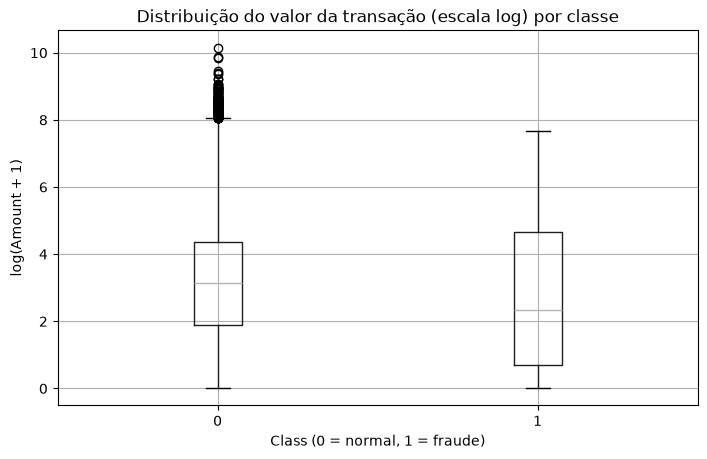

In [9]:
import matplotlib.pyplot as plt
import numpy as np

df['Amount_log'] = np.log1p(df['Amount'])

fig, ax = plt.subplots(figsize=(8, 5))
df.boxplot(column='Amount_log', by='Class', ax=ax)
plt.title('Distribuição do valor da transação (escala log) por classe')
plt.suptitle('')
plt.xlabel('Class (0 = normal, 1 = fraude)')
plt.ylabel('log(Amount + 1)')
plt.show()

In [10]:
from sklearn.model_selection import train_test_split

X = df.drop(['Class', 'Amount_log'], axis=1)   # tudo, exceto o alvo e a coluna que criamos só pra visualização
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,       # <- essa linha é a mais importante aqui
    random_state=42
)

In [11]:
y_train.value_counts(normalize=True)
y_test.value_counts(normalize=True)

Class
0    0.99828
1    0.00172
Name: proportion, dtype: float64

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, average_precision_score

modelo_baseline = LogisticRegression(max_iter=1000, random_state=42)
modelo_baseline.fit(X_train_scaled, y_train)

y_pred = modelo_baseline.predict(X_test_scaled)
y_proba = modelo_baseline.predict_proba(X_test_scaled)[:, 1]  # probabilidade da classe "fraude"

print(classification_report(y_test, y_pred, digits=3))
print("AUPRC:", average_precision_score(y_test, y_proba))

              precision    recall  f1-score   support

           0      0.999     1.000     1.000     56864
           1      0.827     0.633     0.717        98

    accuracy                          0.999     56962
   macro avg      0.913     0.816     0.858     56962
weighted avg      0.999     0.999     0.999     56962

AUPRC: 0.7413820992780461


In [14]:
modelo_balanced = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
modelo_balanced.fit(X_train_scaled, y_train)

y_pred_bal = modelo_balanced.predict(X_test_scaled)
y_proba_bal = modelo_balanced.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred_bal, digits=3))
print("AUPRC:", average_precision_score(y_test, y_proba_bal))

              precision    recall  f1-score   support

           0      1.000     0.976     0.988     56864
           1      0.061     0.918     0.114        98

    accuracy                          0.976     56962
   macro avg      0.530     0.947     0.551     56962
weighted avg      0.998     0.976     0.986     56962

AUPRC: 0.7189705771419241


In [15]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

y_train_smote.value_counts()

Class
0    227451
1    227451
Name: count, dtype: int64

In [16]:
modelo_smote = LogisticRegression(max_iter=1000, random_state=42)
modelo_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = modelo_smote.predict(X_test_scaled)   # repare: testamos no X_test ORIGINAL, nunca reamostrado
y_proba_smote = modelo_smote.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred_smote, digits=3))
print("AUPRC:", average_precision_score(y_test, y_proba_smote))

              precision    recall  f1-score   support

           0      1.000     0.974     0.987     56864
           1      0.058     0.918     0.109        98

    accuracy                          0.974     56962
   macro avg      0.529     0.946     0.548     56962
weighted avg      0.998     0.974     0.985     56962

AUPRC: 0.724469435669471


In [17]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

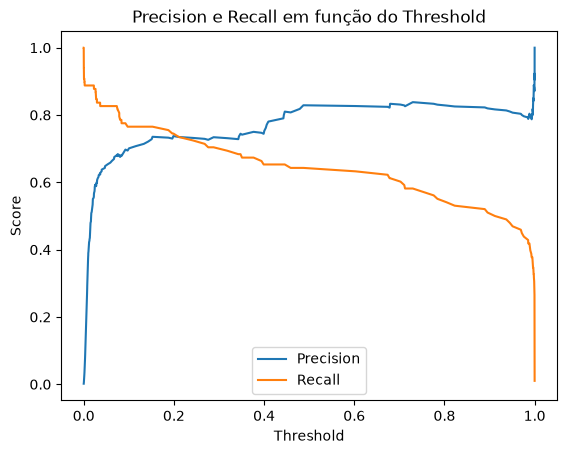

In [18]:
import matplotlib.pyplot as plt

plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.legend()
plt.title('Precision e Recall em função do Threshold')
plt.show()

In [19]:
import numpy as np

precision_minima = 0.70
indices_validos = np.where(precisions[:-1] >= precision_minima)[0]

melhor_indice = indices_validos[np.argmax(recalls[:-1][indices_validos])]
melhor_threshold = thresholds[melhor_indice]

print(f"Threshold escolhido: {melhor_threshold:.4f}")
print(f"Precision nesse ponto: {precisions[melhor_indice]:.3f}")
print(f"Recall nesse ponto: {recalls[melhor_indice]:.3f}")

Threshold escolhido: 0.1004
Precision nesse ponto: 0.701
Recall nesse ponto: 0.765


In [20]:
from sklearn.metrics import classification_report

y_pred_threshold = (y_proba >= melhor_threshold).astype(int)
print(classification_report(y_test, y_pred_threshold, digits=3))

              precision    recall  f1-score   support

           0      1.000     0.999     1.000     56864
           1      0.701     0.765     0.732        98

    accuracy                          0.999     56962
   macro avg      0.850     0.882     0.866     56962
weighted avg      0.999     0.999     0.999     56962



In [21]:
from xgboost import XGBClassifier

modelo_xgb = XGBClassifier(
    random_state=42,
    eval_metric='aucpr'
)
modelo_xgb.fit(X_train_scaled, y_train)

y_pred_xgb = modelo_xgb.predict(X_test_scaled)
y_proba_xgb = modelo_xgb.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred_xgb, digits=3))
print("AUPRC:", average_precision_score(y_test, y_proba_xgb))

              precision    recall  f1-score   support

           0      1.000     1.000     1.000     56864
           1      0.897     0.796     0.843        98

    accuracy                          0.999     56962
   macro avg      0.948     0.898     0.921     56962
weighted avg      0.999     0.999     0.999     56962

AUPRC: 0.7813171412660339


In [22]:
proporcao = y_train.value_counts()[0] / y_train.value_counts()[1]
print(proporcao)  # deve dar algo perto de 577 (284315/492 * 0.8, aproximadamente)

modelo_xgb_balanced = XGBClassifier(
    random_state=42,
    eval_metric='aucpr',
    scale_pos_weight=proporcao
)
modelo_xgb_balanced.fit(X_train_scaled, y_train)

y_pred_xgb_bal = modelo_xgb_balanced.predict(X_test_scaled)
y_proba_xgb_bal = modelo_xgb_balanced.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred_xgb_bal, digits=3))
print("AUPRC:", average_precision_score(y_test, y_proba_xgb_bal))

577.2868020304569
              precision    recall  f1-score   support

           0      1.000     1.000     1.000     56864
           1      0.871     0.827     0.848        98

    accuracy                          0.999     56962
   macro avg      0.935     0.913     0.924     56962
weighted avg      0.999     0.999     0.999     56962

AUPRC: 0.8790551796218564


In [23]:
precisions_xgb, recalls_xgb, thresholds_xgb = precision_recall_curve(y_test, y_proba_xgb_bal)

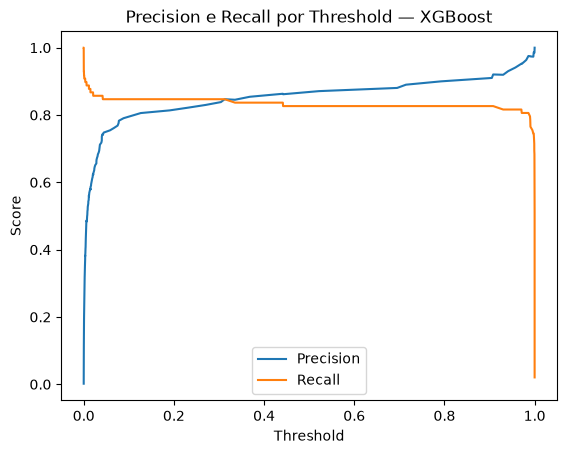

In [24]:
plt.plot(thresholds_xgb, precisions_xgb[:-1], label='Precision')
plt.plot(thresholds_xgb, recalls_xgb[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.legend()
plt.title('Precision e Recall por Threshold — XGBoost')
plt.show()

In [25]:
for precision_minima in [0.70, 0.80, 0.85, 0.90]:
    indices_validos = np.where(precisions_xgb[:-1] >= precision_minima)[0]
    if len(indices_validos) == 0:
        print(f"Precision mínima {precision_minima}: nenhum threshold atinge esse nível")
        continue
    melhor_indice = indices_validos[np.argmax(recalls_xgb[:-1][indices_validos])]
    melhor_threshold = thresholds_xgb[melhor_indice]
    print(f"Precision mínima {precision_minima:.2f} -> threshold={melhor_threshold:.4f} | "
          f"precision={precisions_xgb[melhor_indice]:.3f} | recall={recalls_xgb[melhor_indice]:.3f}")

Precision mínima 0.70 -> threshold=0.0349 | precision=0.700 | recall=0.857
Precision mínima 0.80 -> threshold=0.1265 | precision=0.806 | recall=0.847
Precision mínima 0.85 -> threshold=0.3681 | precision=0.854 | recall=0.837
Precision mínima 0.90 -> threshold=0.7924 | precision=0.900 | recall=0.827


In [26]:
y_pred_final = (y_proba_xgb_bal >= melhor_threshold).astype(int)
print(classification_report(y_test, y_pred_final, digits=3))

              precision    recall  f1-score   support

           0      1.000     1.000     1.000     56864
           1      0.900     0.827     0.862        98

    accuracy                          1.000     56962
   macro avg      0.950     0.913     0.931     56962
weighted avg      1.000     1.000     1.000     56962



In [27]:
import pandas as pd

importancias = pd.DataFrame({
    'feature': X_train.columns,
    'importancia': modelo_xgb_balanced.feature_importances_
}).sort_values('importancia', ascending=False)

print(importancias.head(10))

   feature  importancia
14     V14     0.598660
4       V4     0.062090
12     V12     0.043427
8       V8     0.021423
29  Amount     0.019511
7       V7     0.019142
20     V20     0.017877
13     V13     0.017096
26     V26     0.015676
10     V10     0.013201


In [34]:
print(importancias.head(5)['feature'].tolist())

['V14', 'V4', 'V12', 'V8', 'Amount']


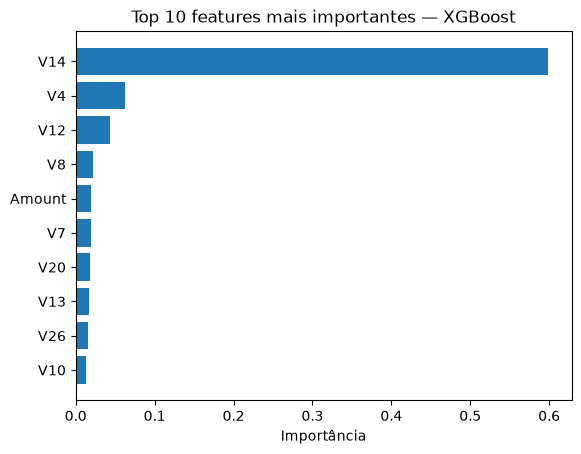

In [28]:
import matplotlib.pyplot as plt

top10 = importancias.head(10)
plt.barh(top10['feature'], top10['importancia'])
plt.xlabel('Importância')
plt.title('Top 10 features mais importantes — XGBoost')
plt.gca().invert_yaxis()
plt.show()

In [29]:
import joblib

joblib.dump(modelo_xgb_balanced, 'modelo_fraude_xgb.pkl')
joblib.dump(scaler, 'scaler.pkl')

threshold_final = 0.7924   

with open('threshold.txt', 'w') as f:
    f.write(str(threshold_final))

In [30]:
X_test.iloc[0].to_dict()

{'Time': 160760.0,
 'V1': -0.674466064578314,
 'V2': 1.40810501967799,
 'V3': -1.11062205357093,
 'V4': -1.32836577843066,
 'V5': 1.38899603254837,
 'V6': -1.30843906707795,
 'V7': 1.88587890268717,
 'V8': -0.614232966299775,
 'V9': 0.311652212453101,
 'V10': 0.65075700363522,
 'V11': -0.857784661547805,
 'V12': -0.229961445775592,
 'V13': -0.19981700479103,
 'V14': 0.266371326329879,
 'V15': -0.0465441684754424,
 'V16': -0.741398089749789,
 'V17': -0.605616644106022,
 'V18': -0.39256818789208,
 'V19': -0.162648311024695,
 'V20': 0.394321820843914,
 'V21': 0.0800842396026648,
 'V22': 0.810033595602455,
 'V23': -0.224327230436412,
 'V24': 0.707899237446867,
 'V25': -0.13583702273753,
 'V26': 0.0451021964988772,
 'V27': 0.533837219064273,
 'V28': 0.291319252625364,
 'Amount': 23.0}

In [31]:
import json

print(json.dumps(X_test.iloc[0].to_dict()))

{"Time": 160760.0, "V1": -0.674466064578314, "V2": 1.40810501967799, "V3": -1.11062205357093, "V4": -1.32836577843066, "V5": 1.38899603254837, "V6": -1.30843906707795, "V7": 1.88587890268717, "V8": -0.614232966299775, "V9": 0.311652212453101, "V10": 0.65075700363522, "V11": -0.857784661547805, "V12": -0.229961445775592, "V13": -0.19981700479103, "V14": 0.266371326329879, "V15": -0.0465441684754424, "V16": -0.741398089749789, "V17": -0.605616644106022, "V18": -0.39256818789208, "V19": -0.162648311024695, "V20": 0.394321820843914, "V21": 0.0800842396026648, "V22": 0.810033595602455, "V23": -0.224327230436412, "V24": 0.707899237446867, "V25": -0.13583702273753, "V26": 0.0451021964988772, "V27": 0.533837219064273, "V28": 0.291319252625364, "Amount": 23.0}


In [32]:
X_test[y_test == 1].iloc[0].to_dict()

{'Time': 57007.0,
 'V1': -1.27124419171437,
 'V2': 2.46267526851135,
 'V3': -2.85139500331783,
 'V4': 2.3244800653478,
 'V5': -1.37224488981369,
 'V6': -0.948195686538643,
 'V7': -3.06523436172054,
 'V8': 1.16692694787211,
 'V9': -2.26877058844813,
 'V10': -4.88114292689057,
 'V11': 2.25514748870463,
 'V12': -4.68638689759229,
 'V13': 0.652374668512965,
 'V14': -6.17428834800643,
 'V15': 0.594379608016446,
 'V16': -4.84969238709652,
 'V17': -6.53652073527011,
 'V18': -3.11909388163881,
 'V19': 1.71549441975915,
 'V20': 0.560478075726644,
 'V21': 0.652941051330455,
 'V22': 0.0819309763507574,
 'V23': -0.221347831198339,
 'V24': -0.523582159233306,
 'V25': 0.224228161862968,
 'V26': 0.756334522703558,
 'V27': 0.632800477330469,
 'V28': 0.250187092757197,
 'Amount': 0.01}

In [33]:
print(json.dumps(X_test[y_test == 1].iloc[0].to_dict()))

{"Time": 57007.0, "V1": -1.27124419171437, "V2": 2.46267526851135, "V3": -2.85139500331783, "V4": 2.3244800653478, "V5": -1.37224488981369, "V6": -0.948195686538643, "V7": -3.06523436172054, "V8": 1.16692694787211, "V9": -2.26877058844813, "V10": -4.88114292689057, "V11": 2.25514748870463, "V12": -4.68638689759229, "V13": 0.652374668512965, "V14": -6.17428834800643, "V15": 0.594379608016446, "V16": -4.84969238709652, "V17": -6.53652073527011, "V18": -3.11909388163881, "V19": 1.71549441975915, "V20": 0.560478075726644, "V21": 0.652941051330455, "V22": 0.0819309763507574, "V23": -0.221347831198339, "V24": -0.523582159233306, "V25": 0.224228161862968, "V26": 0.756334522703558, "V27": 0.632800477330469, "V28": 0.250187092757197, "Amount": 0.01}
